----- Comparison for PEHE (Variant 1) -----
Model              BCF            wsBCF
   1k  9.913 +/- 2.538  9.970 +/- 2.655
 0.5k 10.005 +/- 2.702 10.239 +/- 2.811
0.25k 10.187 +/- 2.673 10.493 +/- 3.103
 0.1k 10.054 +/- 2.615 13.055 +/- 4.913
0.05k 10.236 +/- 2.554 17.610 +/- 9.646




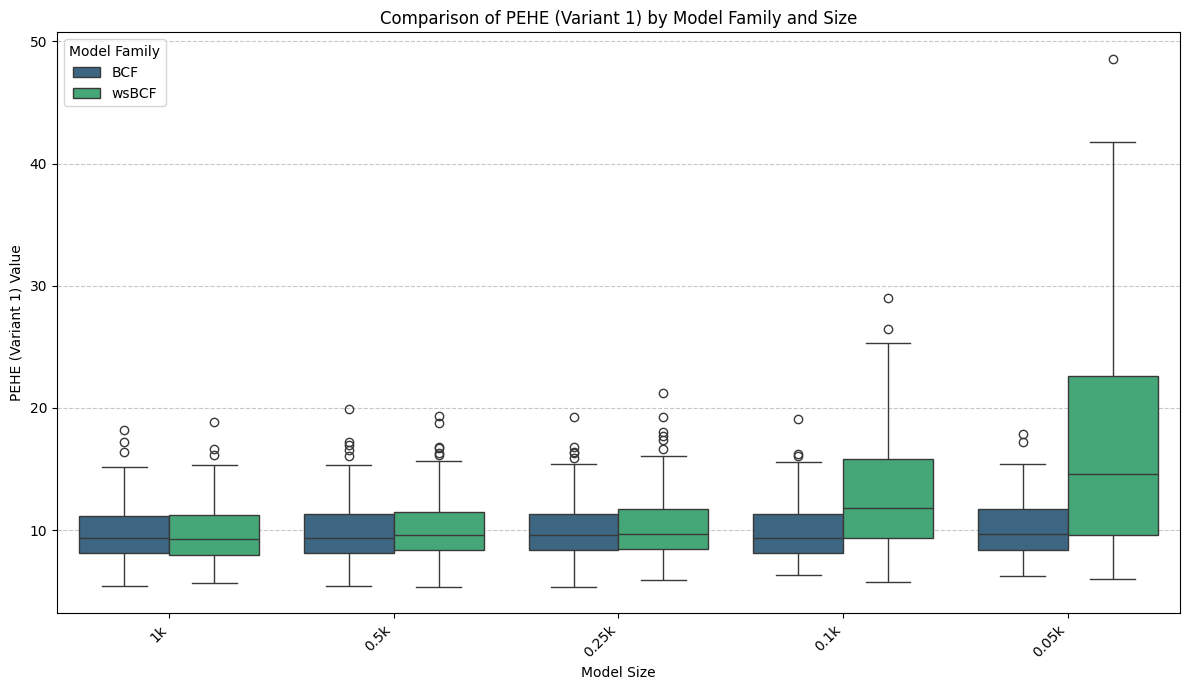

----- Comparison for PEHE (Variant 2) -----
Model              BCF            wsBCF
   1k  9.958 +/- 1.941 10.009 +/- 2.104
 0.5k 10.031 +/- 2.006 10.151 +/- 2.170
0.25k 10.009 +/- 2.089 10.502 +/- 2.616
 0.1k 10.075 +/- 2.159 11.908 +/- 4.135
0.05k 10.466 +/- 2.210 13.905 +/- 5.922




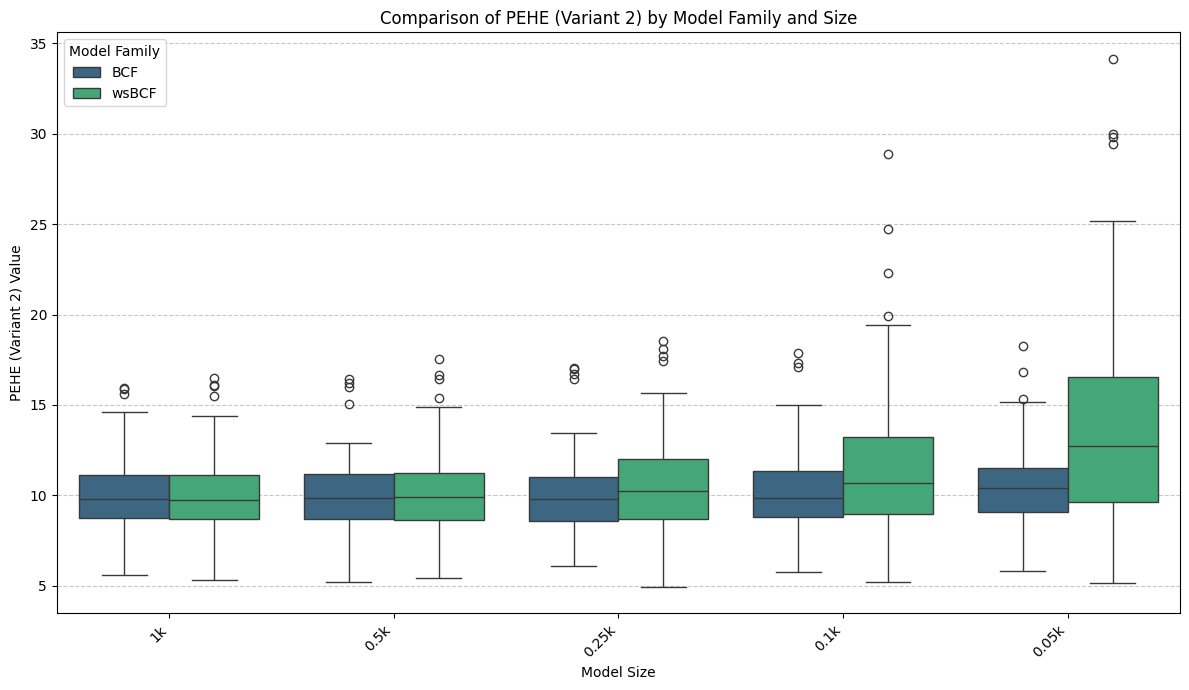

----- Comparison for Tau_95 (Variant 1) -----
Model             BCF           wsBCF
   1k 0.961 +/- 0.069 0.970 +/- 0.066
 0.5k 0.956 +/- 0.074 0.973 +/- 0.067
0.25k 0.950 +/- 0.074 0.973 +/- 0.075
 0.1k 0.946 +/- 0.092 0.952 +/- 0.126
0.05k 0.926 +/- 0.077 0.833 +/- 0.270




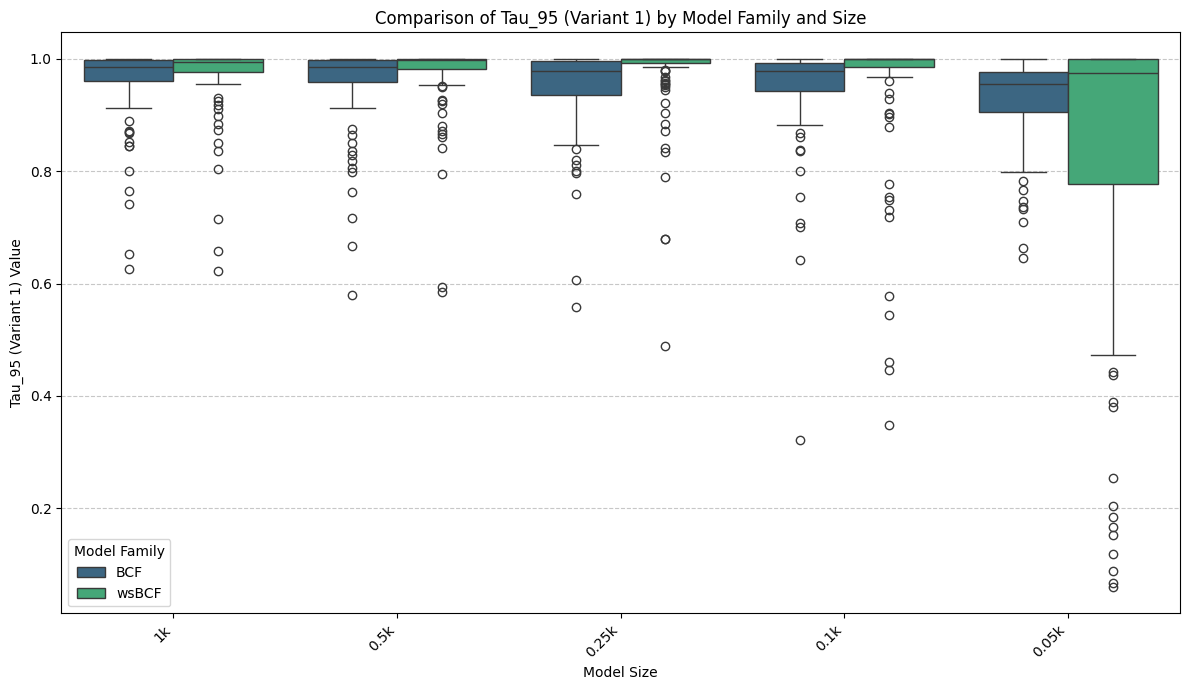

----- Comparison for Tau_95 (Variant 2) -----
Model             BCF           wsBCF
   1k 0.963 +/- 0.051 0.976 +/- 0.040
 0.5k 0.959 +/- 0.052 0.976 +/- 0.043
0.25k 0.954 +/- 0.065 0.978 +/- 0.045
 0.1k 0.942 +/- 0.069 0.981 +/- 0.057
0.05k 0.920 +/- 0.076 0.916 +/- 0.163




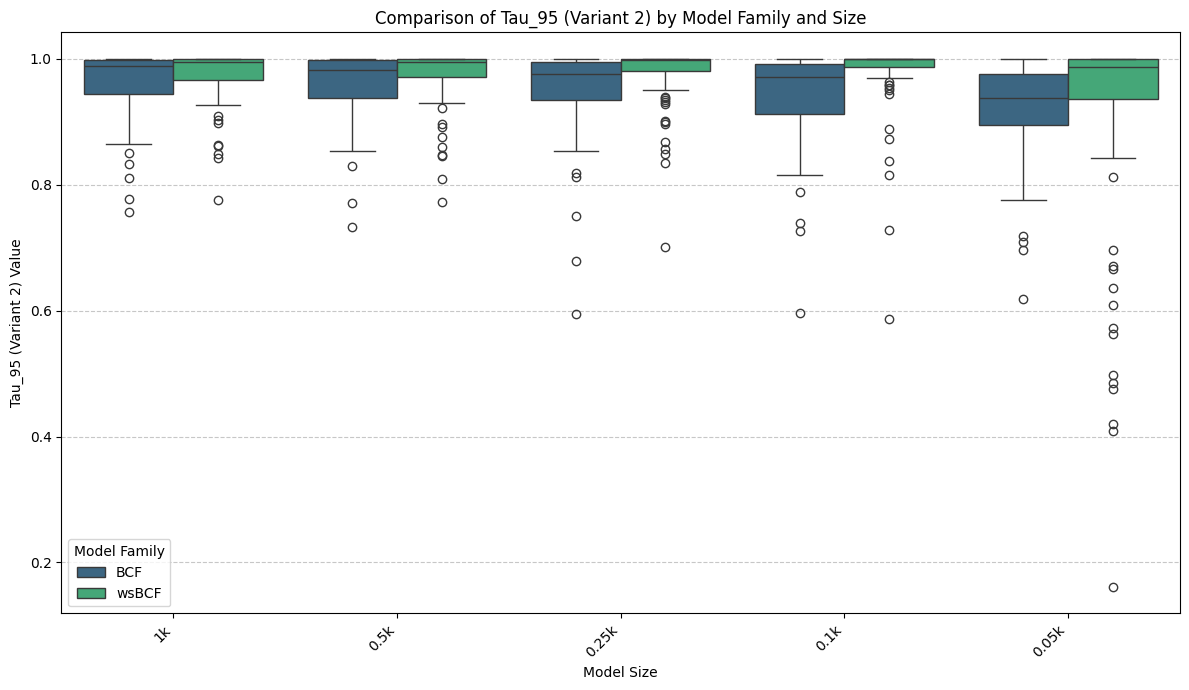

----- Comparison for Tau_95w (Variant 1) -----
Model              BCF             wsBCF
   1k 45.069 +/- 7.305  48.968 +/- 8.210
 0.5k 44.400 +/- 7.395 55.021 +/- 13.621
0.25k 43.943 +/- 7.474 63.251 +/- 16.834
 0.1k 43.225 +/- 6.861 79.102 +/- 30.319
0.05k 41.079 +/- 7.416 66.928 +/- 33.903




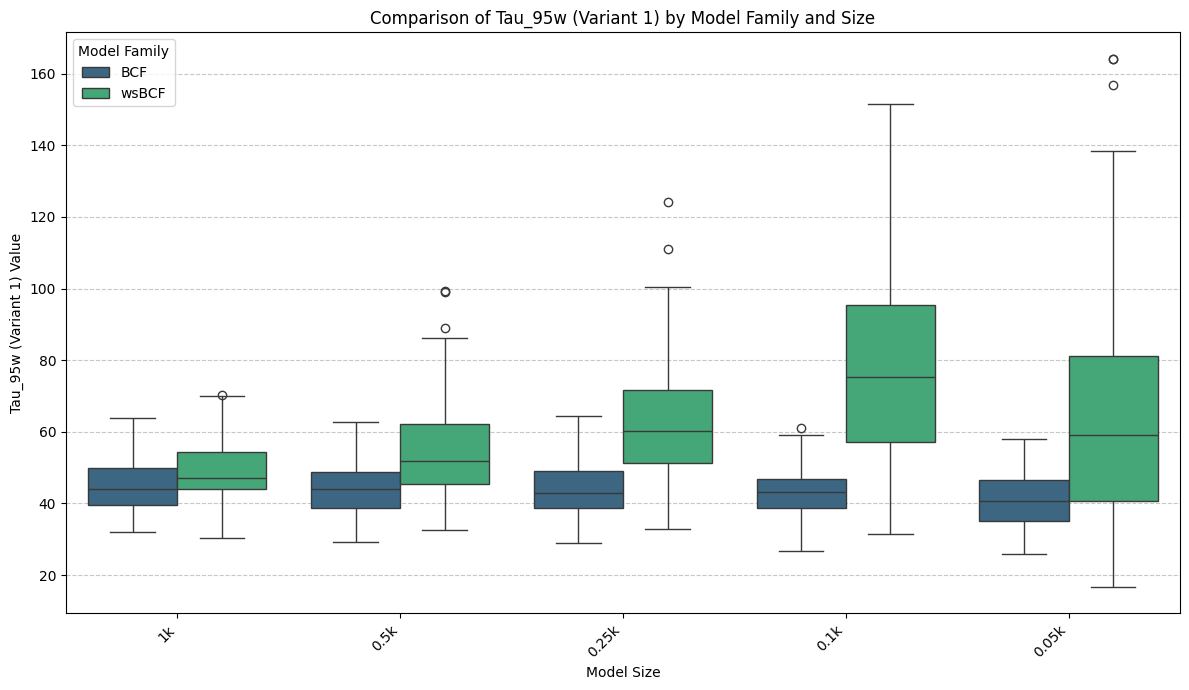

----- Comparison for Tau_95w (Variant 2) -----
Model              BCF             wsBCF
   1k 43.734 +/- 5.598  48.172 +/- 6.319
 0.5k 43.357 +/- 6.457 51.561 +/- 10.038
0.25k 43.007 +/- 6.076 59.666 +/- 13.789
 0.1k 41.597 +/- 6.352 77.041 +/- 27.609
0.05k 40.791 +/- 7.055 63.775 +/- 23.670




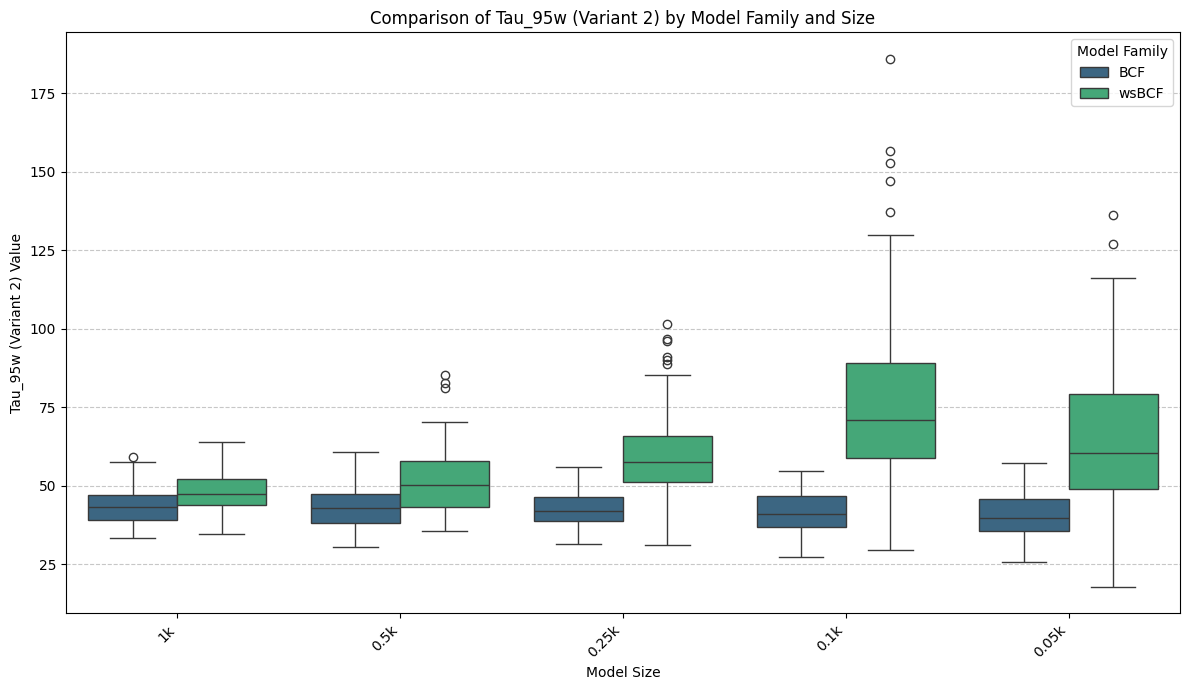

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    # Renamed df_mvbcf to df_bcf and loaded from BCF_simulation_results_DGP1.csv
    df_bcf = pd.read_csv("BCF_simulation_results_DGP1.csv")
    # Renamed df_wsmvbcf to df_wsbcf and loaded from wsBCF_simulation_results_DGP1.csv
    df_wsbcf = pd.read_csv("wsBCF_simulation_results_DGP1.csv")
    
    # Removed XMVBCF loading as per request.
    
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files (BCF_simulation_results_DGP1.csv and wsBCF_simulation_results_DGP1.csv) are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
# Corrected 'MVBCF' to 'BCF'
df_bcf['model_family'] = 'BCF'
df_wsbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine only BCF and wsBCF DataFrames
df_combined = pd.concat([df_bcf, df_wsbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get BCF results (formerly MVBCF)
        # Column name should be 'bcf_{size}_{metric}'
        bcf_col = f"bcf_{model_size}_{base_name}"
        if bcf_col in df_bcf.columns: # Changed to df_bcf
            mean_bcf = df_bcf[bcf_col].mean()
            std_bcf = df_bcf[bcf_col].std()
            row_data["BCF"] = f"{mean_bcf:.3f} +/- {std_bcf:.3f}"
        else:
            row_data["BCF"] = "N/A"

        # Removed XMVBCF results.
            
        # Get wsBCF results
        # Assuming wsBCF also uses columns prefixed 'bcf_' in its specific file,
        # or adjust prefix if its file uses 'wsbcf_'. Sticking to 'bcf_' as per prompt's spirit.
        wsbcf_col = f"bcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsbcf.columns: # Changed to df_wsbcf
            mean_wsbcf = df_wsbcf[wsbcf_col].mean()
            std_wsbcf = df_wsbcf[wsbcf_col].std()
            row_data["wsBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting - prefix should be 'bcf_' for both models as per column naming convention assumed
    plot_cols_prefix = "bcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()

----- Comparison for PEHE (Variant 1) -----
Model              BCF            wsBCF
   1k 11.285 +/- 2.913 11.297 +/- 2.931
 0.5k 11.303 +/- 2.913 11.566 +/- 2.944
0.25k 11.289 +/- 2.720 12.097 +/- 3.591
 0.1k 11.517 +/- 2.977 13.648 +/- 4.554
0.05k 11.575 +/- 2.915 16.903 +/- 7.239




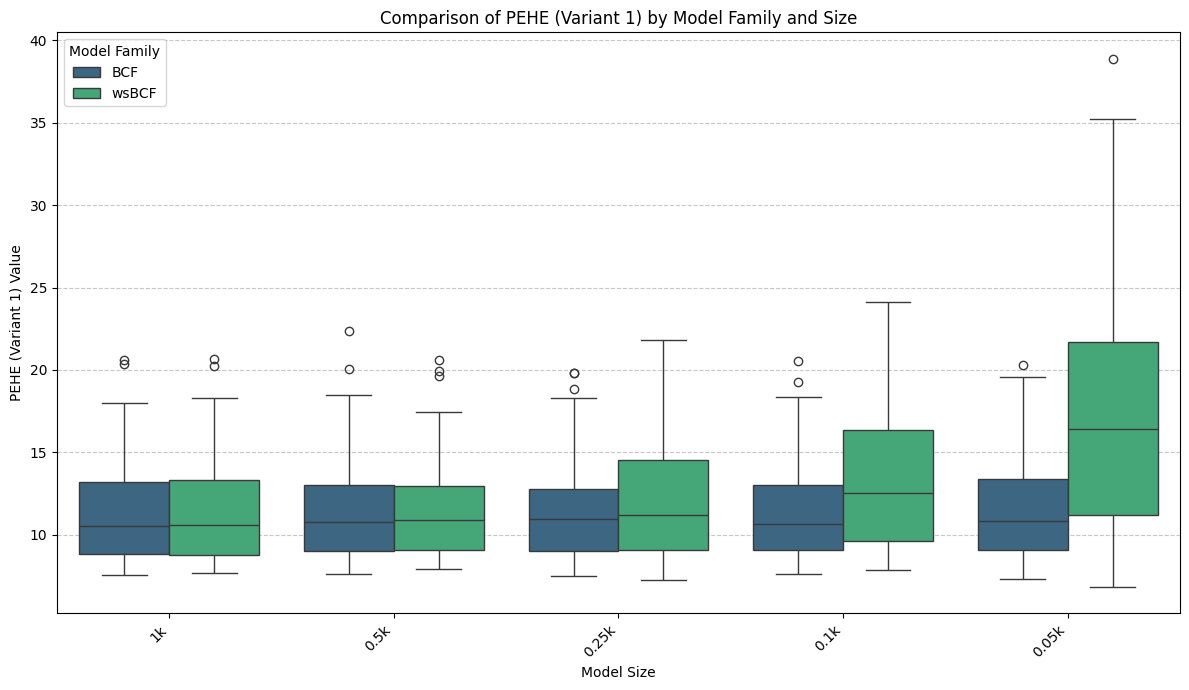

----- Comparison for PEHE (Variant 2) -----
Model              BCF            wsBCF
   1k 10.088 +/- 1.951 10.082 +/- 2.003
 0.5k 10.165 +/- 1.906 10.269 +/- 2.008
0.25k 10.162 +/- 2.064 10.522 +/- 2.365
 0.1k 10.106 +/- 1.876 12.211 +/- 4.504
0.05k 10.225 +/- 1.939 14.485 +/- 6.738




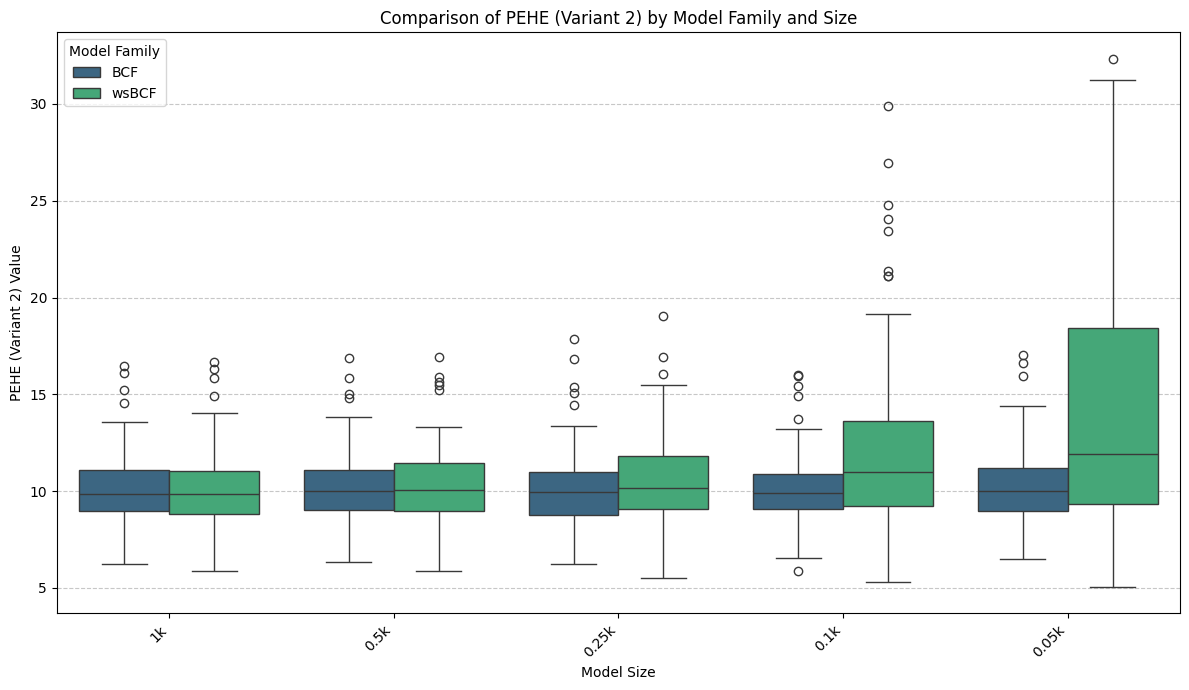

----- Comparison for Tau_95 (Variant 1) -----
Model             BCF           wsBCF
   1k 0.942 +/- 0.090 0.954 +/- 0.084
 0.5k 0.938 +/- 0.099 0.955 +/- 0.090
0.25k 0.938 +/- 0.089 0.943 +/- 0.117
 0.1k 0.921 +/- 0.104 0.944 +/- 0.133
0.05k 0.900 +/- 0.117 0.857 +/- 0.239




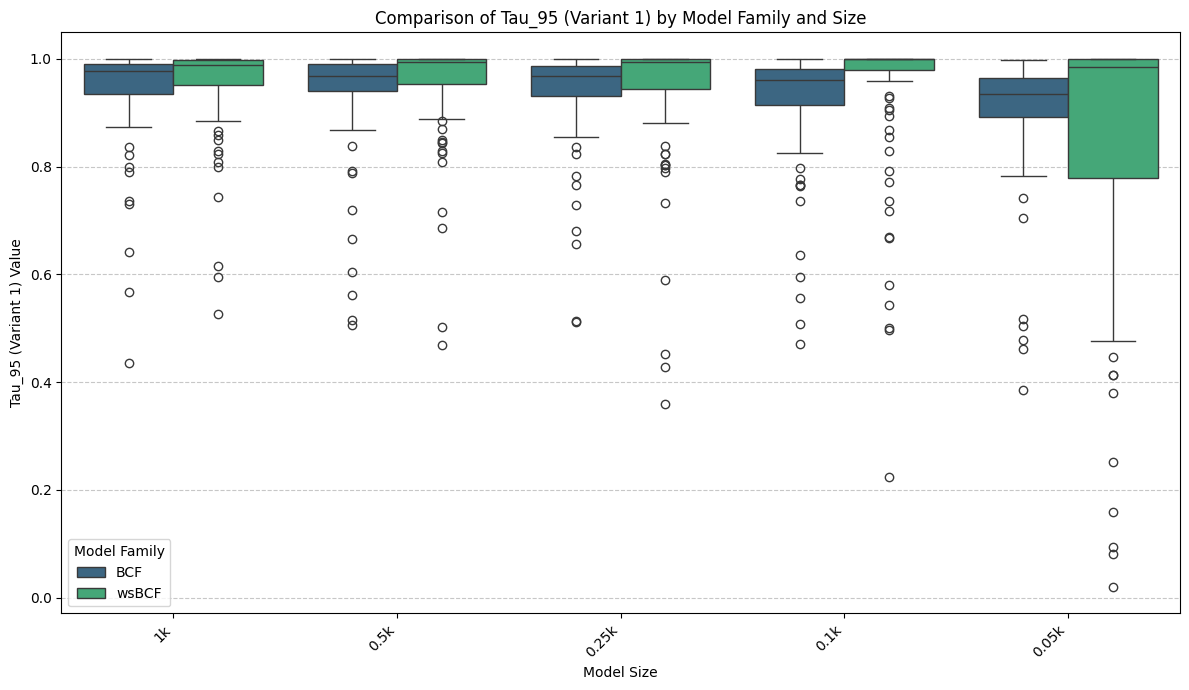

----- Comparison for Tau_95 (Variant 2) -----
Model             BCF           wsBCF
   1k 0.954 +/- 0.051 0.970 +/- 0.046
 0.5k 0.950 +/- 0.056 0.972 +/- 0.043
0.25k 0.944 +/- 0.062 0.970 +/- 0.064
 0.1k 0.933 +/- 0.062 0.972 +/- 0.084
0.05k 0.904 +/- 0.077 0.891 +/- 0.209




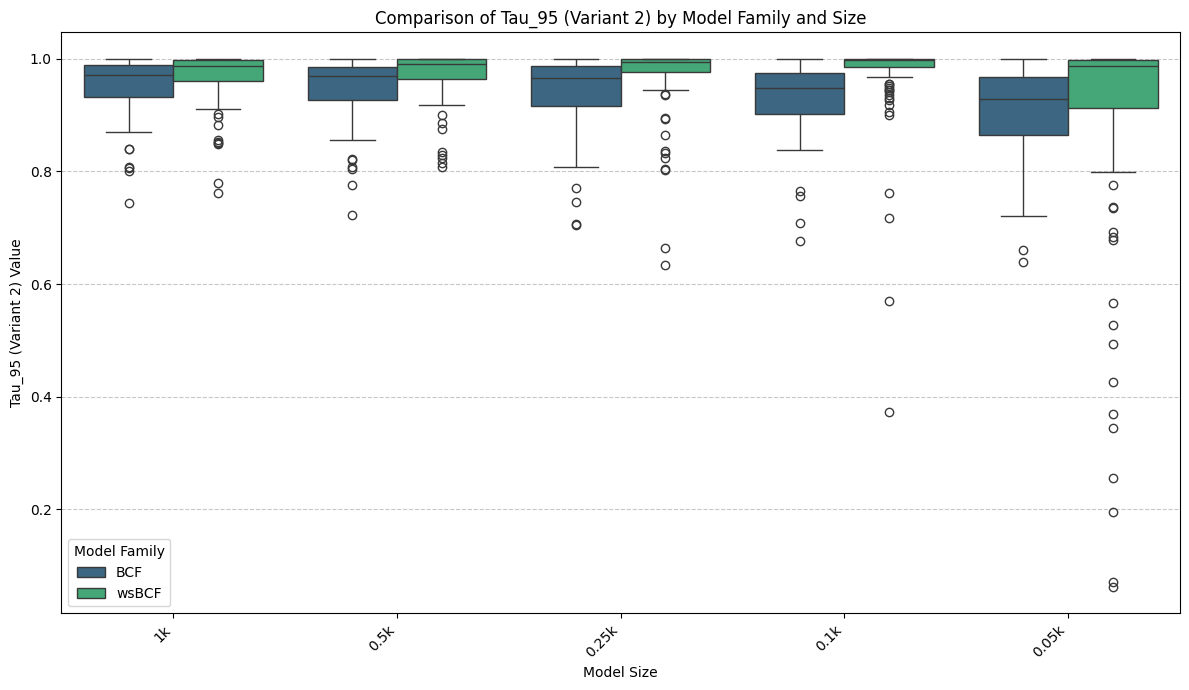

----- Comparison for Tau_95w (Variant 1) -----
Model              BCF             wsBCF
   1k 46.556 +/- 7.504  51.042 +/- 8.737
 0.5k 46.258 +/- 7.533 55.912 +/- 12.110
0.25k 45.844 +/- 7.234 61.152 +/- 17.302
 0.1k 45.136 +/- 7.472 77.642 +/- 27.902
0.05k 42.888 +/- 7.465 71.950 +/- 34.896




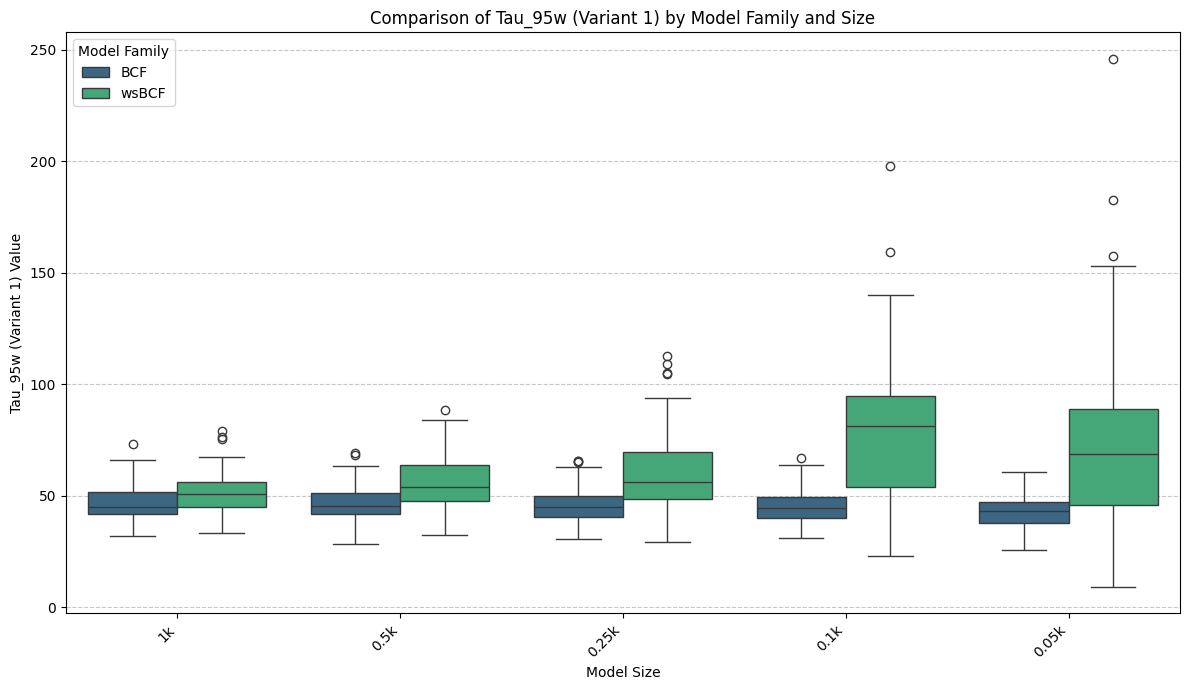

----- Comparison for Tau_95w (Variant 2) -----
Model              BCF             wsBCF
   1k 41.655 +/- 5.179  45.773 +/- 5.832
 0.5k 41.826 +/- 5.527  50.029 +/- 8.464
0.25k 41.331 +/- 5.159 56.055 +/- 15.166
 0.1k 39.762 +/- 5.292 73.753 +/- 24.016
0.05k 37.570 +/- 6.026 63.163 +/- 23.327




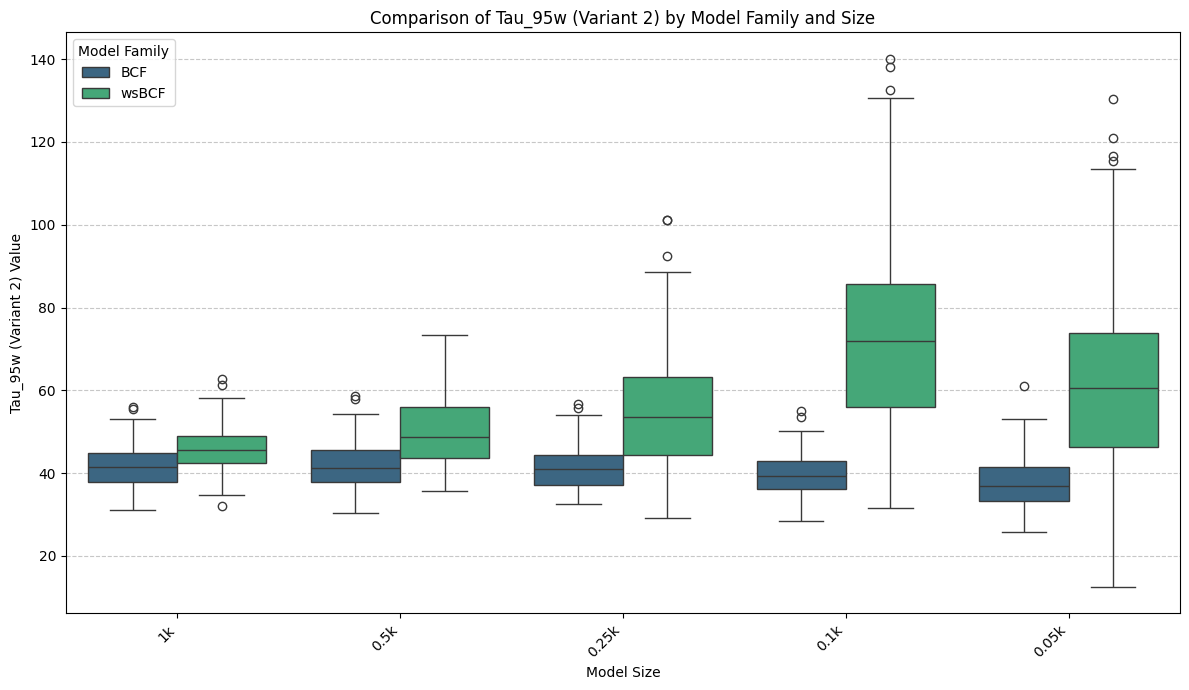

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    # Renamed df_mvbcf to df_bcf and loaded from BCF_simulation_results_DGP1.csv
    df_bcf = pd.read_csv("BCF_simulation_results_DGP2.csv")
    # Renamed df_wsmvbcf to df_wsbcf and loaded from wsBCF_simulation_results_DGP1.csv
    df_wsbcf = pd.read_csv("wsBCF_simulation_results_DGP2.csv")
    
    # Removed XMVBCF loading as per request.
    
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files (BCF_simulation_results_DGP1.csv and wsBCF_simulation_results_DGP1.csv) are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
# Corrected 'MVBCF' to 'BCF'
df_bcf['model_family'] = 'BCF'
df_wsbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine only BCF and wsBCF DataFrames
df_combined = pd.concat([df_bcf, df_wsbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get BCF results (formerly MVBCF)
        # Column name should be 'bcf_{size}_{metric}'
        bcf_col = f"bcf_{model_size}_{base_name}"
        if bcf_col in df_bcf.columns: # Changed to df_bcf
            mean_bcf = df_bcf[bcf_col].mean()
            std_bcf = df_bcf[bcf_col].std()
            row_data["BCF"] = f"{mean_bcf:.3f} +/- {std_bcf:.3f}"
        else:
            row_data["BCF"] = "N/A"

        # Removed XMVBCF results.
            
        # Get wsBCF results
        # Assuming wsBCF also uses columns prefixed 'bcf_' in its specific file,
        # or adjust prefix if its file uses 'wsbcf_'. Sticking to 'bcf_' as per prompt's spirit.
        wsbcf_col = f"bcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsbcf.columns: # Changed to df_wsbcf
            mean_wsbcf = df_wsbcf[wsbcf_col].mean()
            std_wsbcf = df_wsbcf[wsbcf_col].std()
            row_data["wsBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting - prefix should be 'bcf_' for both models as per column naming convention assumed
    plot_cols_prefix = "bcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()

----- Comparison for PEHE (Variant 1) -----
Model              BCF            wsBCF
   1k  9.904 +/- 2.546  9.890 +/- 2.624
 0.5k  9.847 +/- 2.436 10.219 +/- 2.850
0.25k 10.011 +/- 2.332 10.514 +/- 3.274
 0.1k 10.036 +/- 2.591 12.717 +/- 5.218
0.05k 10.194 +/- 2.571 17.621 +/- 9.615




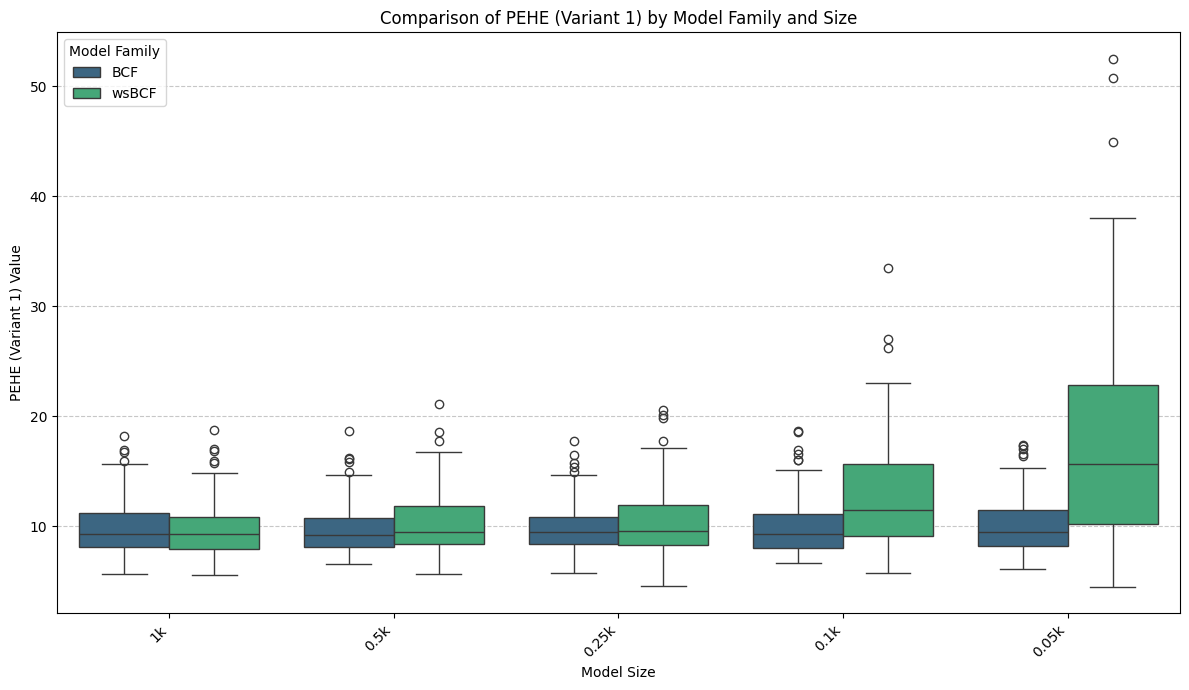

----- Comparison for PEHE (Variant 2) -----
Model              BCF            wsBCF
   1k  9.991 +/- 2.024 10.016 +/- 2.112
 0.5k 10.069 +/- 2.096 10.190 +/- 2.154
0.25k 10.154 +/- 2.062 10.375 +/- 2.471
 0.1k 10.167 +/- 2.155 11.928 +/- 3.902
0.05k 10.200 +/- 2.117 14.692 +/- 7.411




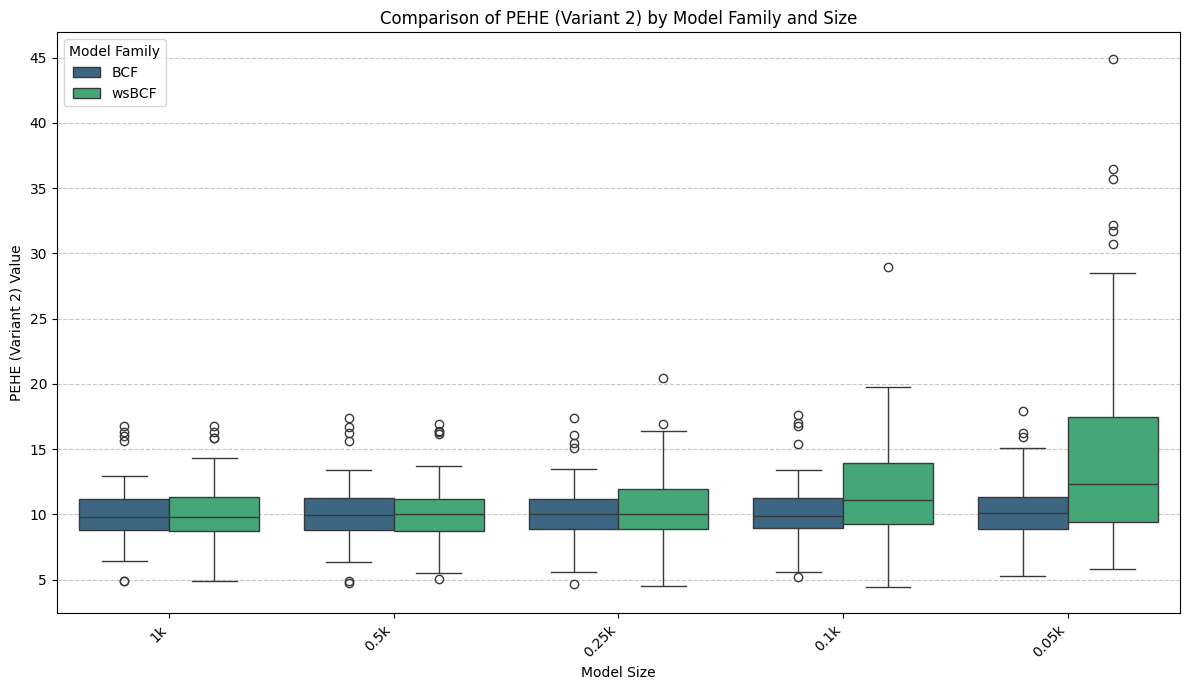

----- Comparison for Tau_95 (Variant 1) -----
Model             BCF           wsBCF
   1k 0.965 +/- 0.062 0.972 +/- 0.058
 0.5k 0.965 +/- 0.061 0.966 +/- 0.084
0.25k 0.955 +/- 0.074 0.967 +/- 0.094
 0.1k 0.947 +/- 0.087 0.938 +/- 0.167
0.05k 0.923 +/- 0.102 0.842 +/- 0.255




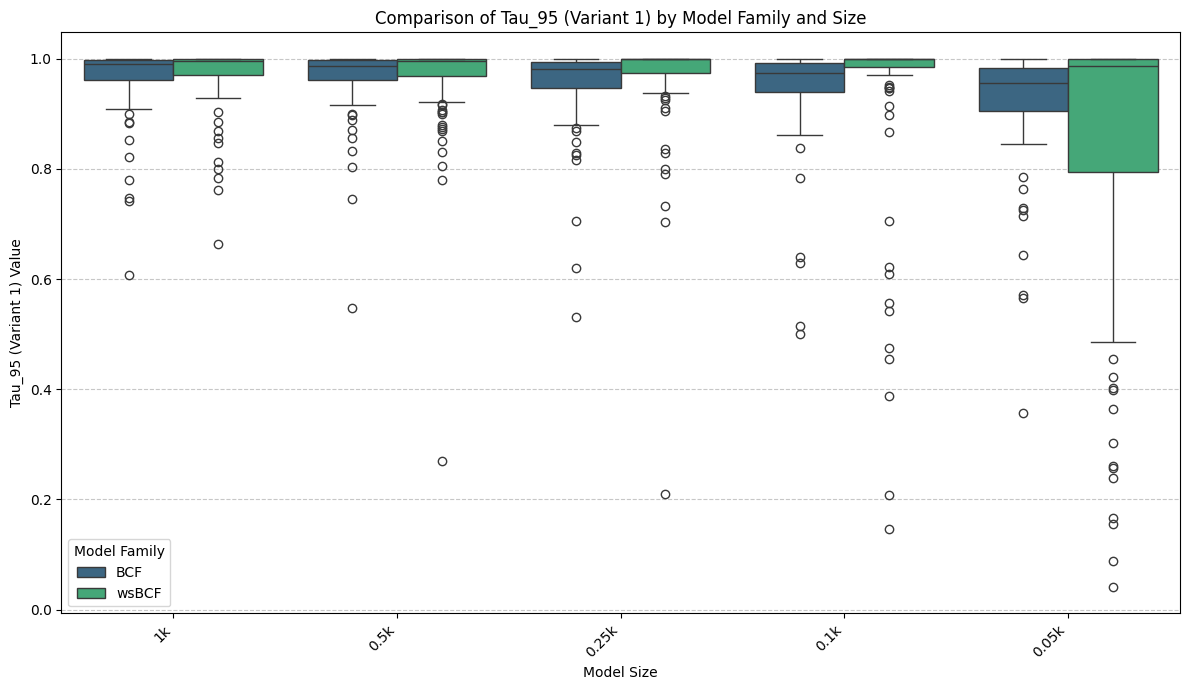

----- Comparison for Tau_95 (Variant 2) -----
Model             BCF           wsBCF
   1k 0.965 +/- 0.045 0.974 +/- 0.043
 0.5k 0.958 +/- 0.053 0.979 +/- 0.040
0.25k 0.953 +/- 0.056 0.984 +/- 0.037
 0.1k 0.938 +/- 0.066 0.980 +/- 0.050
0.05k 0.921 +/- 0.067 0.928 +/- 0.139




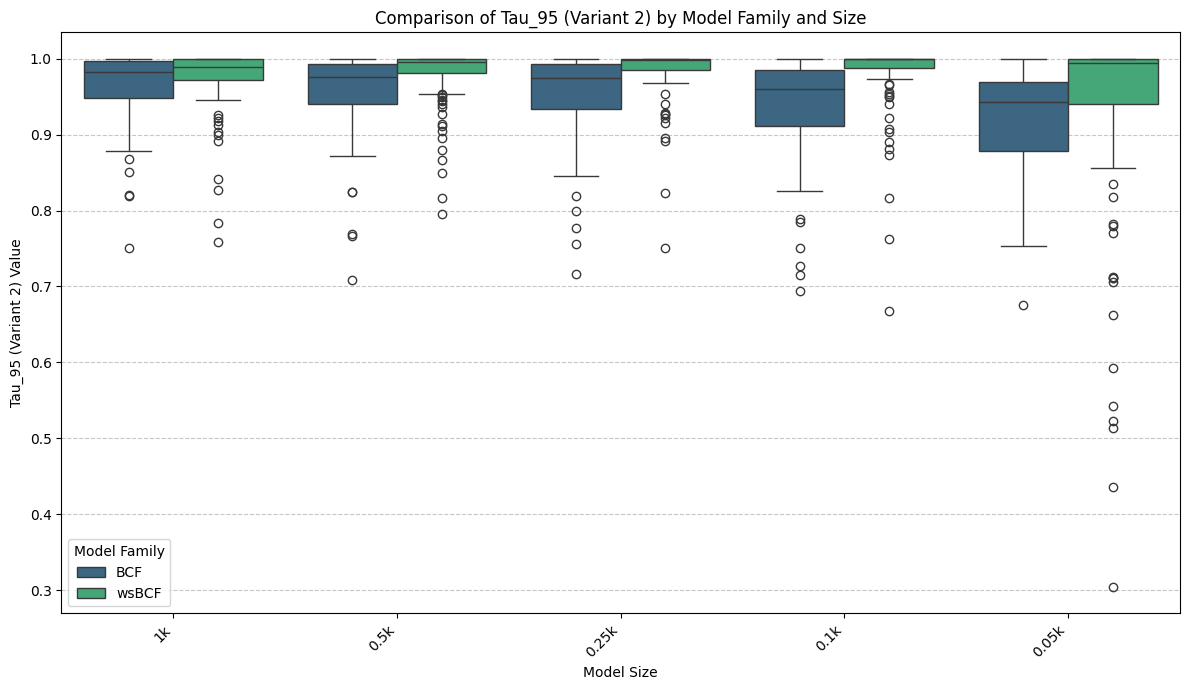

----- Comparison for Tau_95w (Variant 1) -----
Model              BCF             wsBCF
   1k 44.717 +/- 6.890  48.811 +/- 9.015
 0.5k 44.261 +/- 6.768 52.931 +/- 12.094
0.25k 43.379 +/- 6.777 60.474 +/- 16.472
 0.1k 42.807 +/- 6.623 75.952 +/- 29.939
0.05k 41.248 +/- 7.598 67.204 +/- 32.397




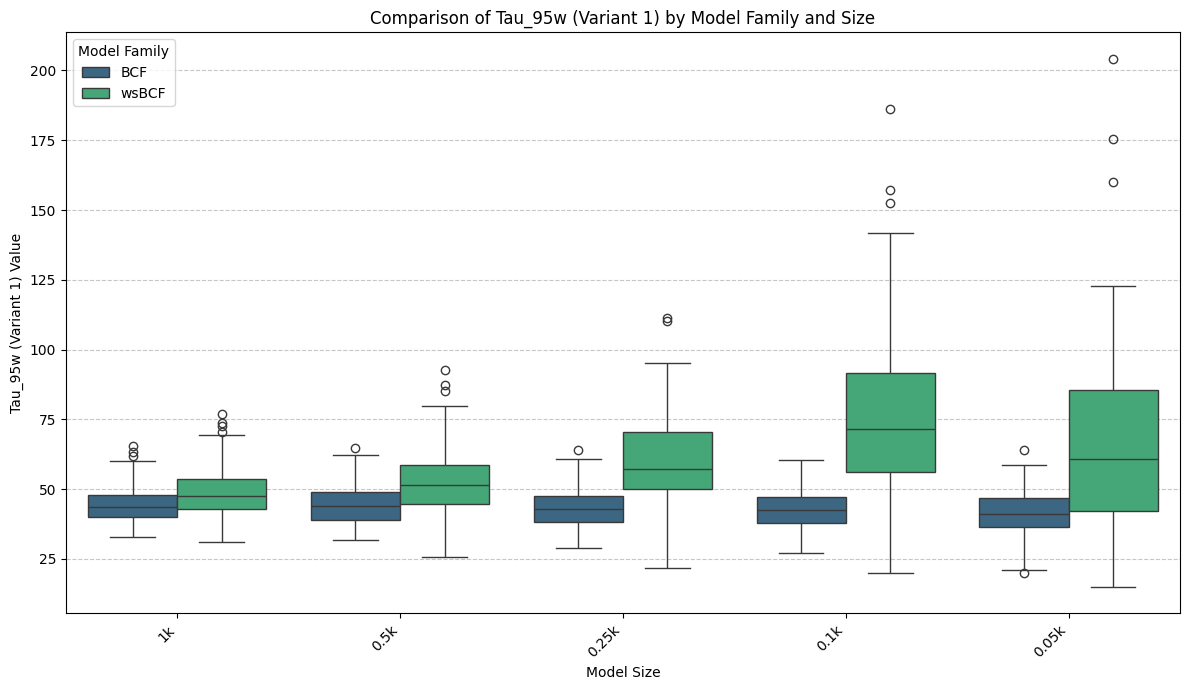

----- Comparison for Tau_95w (Variant 2) -----
Model              BCF             wsBCF
   1k 43.750 +/- 5.773  47.793 +/- 6.784
 0.5k 43.011 +/- 5.985  52.268 +/- 9.098
0.25k 42.846 +/- 6.165 59.817 +/- 12.739
 0.1k 41.261 +/- 6.293 75.640 +/- 26.084
0.05k 39.649 +/- 6.332 69.334 +/- 33.053




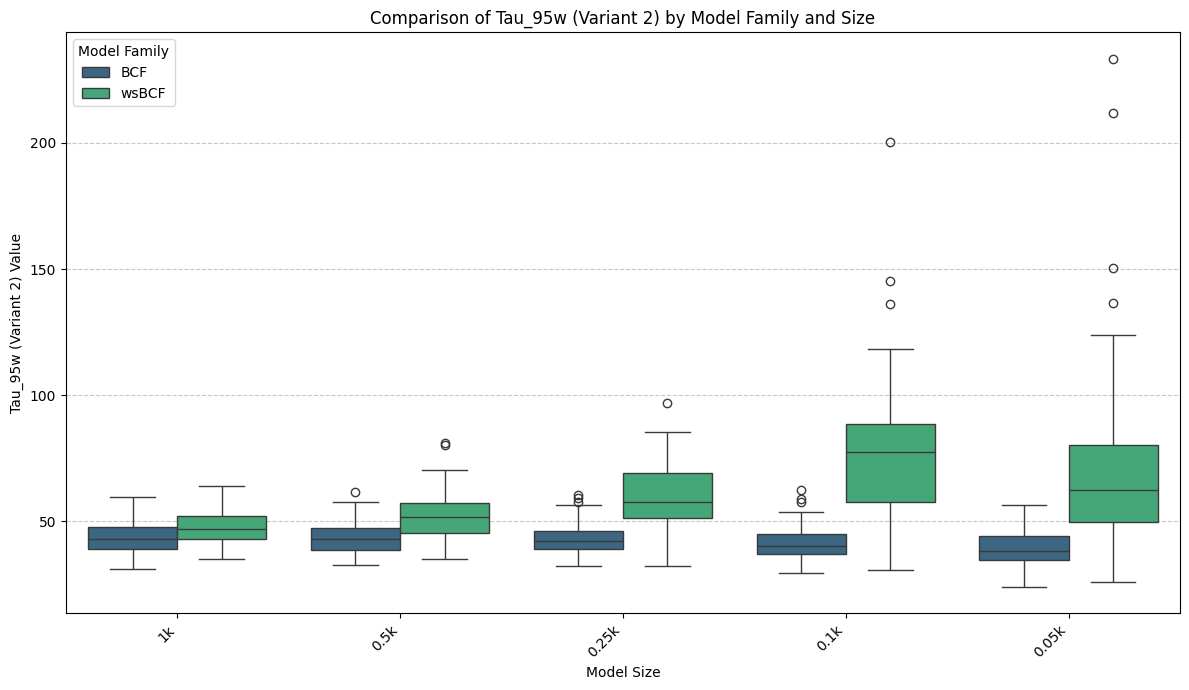

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load the data ---
try:
    # Renamed df_mvbcf to df_bcf and loaded from BCF_simulation_results_DGP1.csv
    df_bcf = pd.read_csv("BCF_simulation_results_DGP3.csv")
    # Renamed df_wsmvbcf to df_wsbcf and loaded from wsBCF_simulation_results_DGP1.csv
    df_wsbcf = pd.read_csv("wsBCF_simulation_results_DGP3.csv")
    
    # Removed XMVBCF loading as per request.
    
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure all CSV files (BCF_simulation_results_DGP1.csv and wsBCF_simulation_results_DGP1.csv) are in the current directory.")
    exit()

# Add a 'model_family' column to each DataFrame for easy distinction
# Corrected 'MVBCF' to 'BCF'
df_bcf['model_family'] = 'BCF'
df_wsbcf['model_family'] = 'wsBCF' # Assign model family for wsBCF

# Combine only BCF and wsBCF DataFrames
df_combined = pd.concat([df_bcf, df_wsbcf], ignore_index=True)

# --- 2. Define Metric Variants and Model Sizes ---
all_metric_variants = {
    "pehe1": {
        "base_name": "pehe1",
        "display_name": "PEHE (Variant 1)"
    },
    "pehe2": {
        "base_name": "pehe2",
        "display_name": "PEHE (Variant 2)"
    },
    "tau_951": {
        "base_name": "tau_951",
        "display_name": "Tau_95 (Variant 1)"
    },
    "tau_952": {
        "base_name": "tau_952",
        "display_name": "Tau_95 (Variant 2)"
    },
    "tau_951w": {
        "base_name": "tau_951w",
        "display_name": "Tau_95w (Variant 1)"
    },
    "tau_952w": {
        "base_name": "tau_952w",
        "display_name": "Tau_95w (Variant 2)"
    }
}

model_sizes = ["1k", "0.5k", "0.25k", "0.1k", "0.05k"] # List of model size strings

# --- 3. Process and Plot for Each Metric Variant ---
for metric_key, metric_info in all_metric_variants.items():
    display_name = metric_info["display_name"]
    base_name = metric_info["base_name"]

    print(f"----- Comparison for {display_name} -----")

    # --- Table Generation ---
    table_results = []
    for model_size in model_sizes:
        row_data = {"Model": model_size}
        
        # Get BCF results (formerly MVBCF)
        # Column name should be 'bcf_{size}_{metric}'
        bcf_col = f"bcf_{model_size}_{base_name}"
        if bcf_col in df_bcf.columns: # Changed to df_bcf
            mean_bcf = df_bcf[bcf_col].mean()
            std_bcf = df_bcf[bcf_col].std()
            row_data["BCF"] = f"{mean_bcf:.3f} +/- {std_bcf:.3f}"
        else:
            row_data["BCF"] = "N/A"

        # Removed XMVBCF results.
            
        # Get wsBCF results
        # Assuming wsBCF also uses columns prefixed 'bcf_' in its specific file,
        # or adjust prefix if its file uses 'wsbcf_'. Sticking to 'bcf_' as per prompt's spirit.
        wsbcf_col = f"bcf_{model_size}_{base_name}"
        if wsbcf_col in df_wsbcf.columns: # Changed to df_wsbcf
            mean_wsbcf = df_wsbcf[wsbcf_col].mean()
            std_wsbcf = df_wsbcf[wsbcf_col].std()
            row_data["wsBCF"] = f"{mean_wsbcf:.3f} +/- {std_wsbcf:.3f}"
        else:
            row_data["wsBCF"] = "N/A"
            
        table_results.append(row_data)

    table_df = pd.DataFrame(table_results)
    print(table_df.to_string(index=False))
    print("\n")

    # --- Box Plot Generation ---
    plt.figure(figsize=(12, 7))

    # Prepare data for plotting - prefix should be 'bcf_' for both models as per column naming convention assumed
    plot_cols_prefix = "bcf_"
    plot_cols_suffix = f"_{base_name}"

    # Filter columns to only include those relevant for this metric (e.g., all _pehe1 columns)
    # from the combined dataframe. This will automatically pick up columns from all included model families.
    relevant_cols = [col for col in df_combined.columns if col.startswith(plot_cols_prefix) and col.endswith(plot_cols_suffix)]
    
    # Create a DataFrame containing only these columns, plus 'model_family'
    df_plot = df_combined[relevant_cols + ['model_family']].copy()

    df_plot.rename(columns={col: col.replace(plot_cols_prefix, '').replace(plot_cols_suffix, '') 
                             for col in relevant_cols}, inplace=True)

    # Melt the DataFrame to long format for Seaborn
    df_melted = df_plot.melt(id_vars=['model_family'], var_name='Model Size', value_name=display_name)

    # Ensure correct order of 'Model Size' on x-axis
    df_melted['Model Size'] = pd.Categorical(df_melted['Model Size'], categories=model_sizes, ordered=True)
    df_melted = df_melted.sort_values('Model Size')

    # Create the box plot using Seaborn, with 'hue' for model_family
    sns.boxplot(data=df_melted, x='Model Size', y=display_name, hue='model_family', palette='viridis')

    plt.title(f"Comparison of {display_name} by Model Family and Size")
    plt.xlabel("Model Size")
    plt.ylabel(f"{display_name} Value")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title="Model Family")
    plt.tight_layout()
    plt.show()